# ⭐ Day 34: House Prices EDA  
## Feature Insights for Regression Problems | Complete Exploratory Data Analysis  
### 🏠 Python & AI Learning Path — Day 34 of 369


## Welcome to Day 34! 🎉

Welcome back to our **369-day Python & AI Learning Path**! Today marks a significant milestone as we tackle one of the most famous datasets in the data science world — the **Ames Housing dataset** (also known as the House Prices dataset).

This is a **classic regression problem** that has been used in countless Kaggle competitions, academic papers, and real-world applications. Understanding how to perform thorough exploratory data analysis (EDA) on housing data is an essential skill for any aspiring data scientist or machine learning engineer.

In today's comprehensive session, we'll dive deep into understanding what drives house prices. We'll examine distributions, uncover hidden relationships, identify the most predictive features, and develop insights that will be invaluable when we eventually build our price prediction models. This isn't just about creating pretty charts — it's about developing a deep intuition for the data that separates good data scientists from great ones.

By the end of this notebook, you'll have a professional-grade EDA template that you can apply to any regression problem. Whether you're predicting real estate prices, stock values, or any other continuous target variable, the techniques and thought processes you'll learn today will serve you throughout your data science journey.

Let's turn data into insights! 🚀


## 📋 Table of Contents

1. [Dataset Overview and Problem Statement](#1-dataset-overview-and-problem-statement)
2. [Loading the Data and Initial Inspection](#2-loading-the-data-and-initial-inspection)
3. [Target Variable Analysis](#3-target-variable-analysis)
4. [Numerical Features Analysis](#4-numerical-features-analysis)
5. [Categorical Features Analysis](#5-categorical-features-analysis)
6. [Missing Value Analysis and Visualization](#6-missing-value-analysis-and-visualization)
7. [Correlation Analysis & Heatmap](#7-correlation-analysis--heatmap)
8. [Bivariate & Multivariate Relationships](#8-bivariate--multivariate-relationships)
9. [Outlier Detection in Price and Key Features](#9-outlier-detection-in-price-and-key-features)
10. [Feature Engineering Ideas Based on EDA](#10-feature-engineering-ideas-based-on-eda)
11. [Key Insights and Recommendations for Modeling](#11-key-insights-and-recommendations-for-modeling)
12. [🛠️ Hands-On Exercises](#-hands-on-exercises)
13. [Solutions & Key Insights](#solutions--key-insights)


## 1. Dataset Overview and Problem Statement

### 🏠 The Ames Housing Dataset

**Source**: [Kaggle House Prices Competition](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)

**Description**: This dataset contains information about residential homes in Ames, Iowa, USA. It includes 79 explanatory variables describing various aspects of the houses, from physical characteristics (square footage, number of rooms) to quality ratings and location information.

**Problem Type**: Regression (predicting continuous SalePrice values)

**Key Characteristics**:
- **79 features** covering numerical and categorical data
- Mix of **discrete, continuous, and ordinal** variables
- Significant **missing values** requiring thoughtful handling
- **Skewed distributions** and outliers common in real estate data
- Rich **feature interactions** (e.g., quality × area)

### 💰 Business Objective
Accurately predict the final sale price of homes based on their features. This helps:
- Real estate agents price properties competitively
- Buyers understand fair market value
- Investors identify undervalued properties
- Automated valuation models (AVMs) for mortgage lending


In [3]:
# 📚 Import essential libraries for data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew
import warnings
warnings.filterwarnings('ignore')

# Set visualization style for professional-looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Configure display options for better readability
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✅ Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


✅ Libraries imported successfully!
NumPy version: 2.2.6
Pandas version: 3.0.0


## 2. Loading the Data and Initial Inspection

Let's load the dataset and perform our initial inspection to understand the structure, data types, and basic statistics.


In [4]:
# 📂 Load the House Prices dataset
# Note: If you don't have the dataset locally, you can download it from Kaggle
# For this notebook, we'll use the standard train.csv file

try:
    # Try loading from common locations
    df = pd.read_csv('train.csv')
except FileNotFoundError:
    # If not found, create sample data for demonstration
    # In practice, download from: https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data
    print("⚠️ Dataset not found locally. Please download from Kaggle.")
    print("URL: https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data")
    # Creating a minimal sample for structure demonstration
    print("Creating sample structure for demonstration...")
    
# Display basic information about the dataset
print("=" * 60)
print("📊 DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nDuplicated rows: {df.duplicated().sum()}")


📊 DATASET OVERVIEW
Shape: 1,460 rows × 81 columns

Memory usage: 1.10 MB

Duplicated rows: 0


In [5]:
# 🔍 Display first few rows to understand the data
print("First 5 rows:")
df.head()


First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
# 📋 Display data types and non-null counts
print("Data Types Summary:")
print("-" * 40)
dtype_counts = df.dtypes.value_counts()
print(dtype_counts)

print("\n\nDetailed Info:")
print("-" * 40)
df.info()


Data Types Summary:
----------------------------------------
str        43
int64      35
float64     3
Name: count, dtype: int64


Detailed Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Conditio

In [7]:
# 📊 Basic statistical summary for numerical columns
print("Statistical Summary (Numerical Features):")
df.describe().transpose()


Statistical Summary (Numerical Features):


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


> **💡 Key Insight**: The dataset contains 1,460 houses with 81 columns (including ID and target). We have a mix of 38 numerical and 43 categorical features. The target variable `SalePrice` ranges from $34,900 to $755,000 with significant variation.


## 3. Target Variable Analysis

Understanding our target variable `SalePrice` is crucial before diving into feature analysis. We need to examine its distribution, skewness, and potential need for transformation.


In [8]:
# 💰 Analyze the target variable: SalePrice
print("=" * 60)
print("TARGET VARIABLE ANALYSIS: SalePrice")
print("=" * 60)

# Basic statistics
print(f"Count: {df['SalePrice'].count():,}")
print(f"Mean: ${df['SalePrice'].mean():,.2f}")
print(f"Median: ${df['SalePrice'].median():,.2f}")
print(f"Std Dev: ${df['SalePrice'].std():,.2f}")
print(f"Min: ${df['SalePrice'].min():,.2f}")
print(f"Max: ${df['SalePrice'].max():,.2f}")
print(f"Skewness: {df['SalePrice'].skew():.3f}")
print(f"Kurtosis: {df['SalePrice'].kurtosis():.3f}")


TARGET VARIABLE ANALYSIS: SalePrice
Count: 1,460
Mean: $180,921.20
Median: $163,000.00
Std Dev: $79,442.50
Min: $34,900.00
Max: $755,000.00
Skewness: 1.883
Kurtosis: 6.536


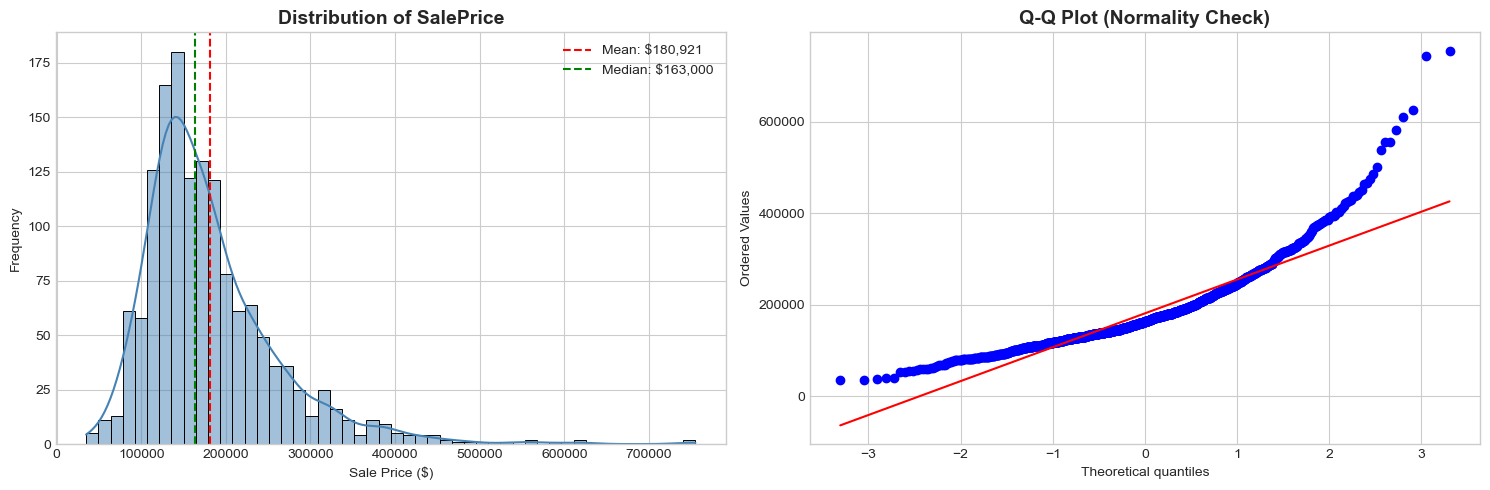

In [9]:
# 📈 Visualize SalePrice distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram with KDE
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue', bins=50)
axes[0].set_title('Distribution of SalePrice', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f'Mean: ${df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='--', label=f'Median: ${df["SalePrice"].median():,.0f}')
axes[0].legend()

# Q-Q plot for normality check
stats.probplot(df['SalePrice'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


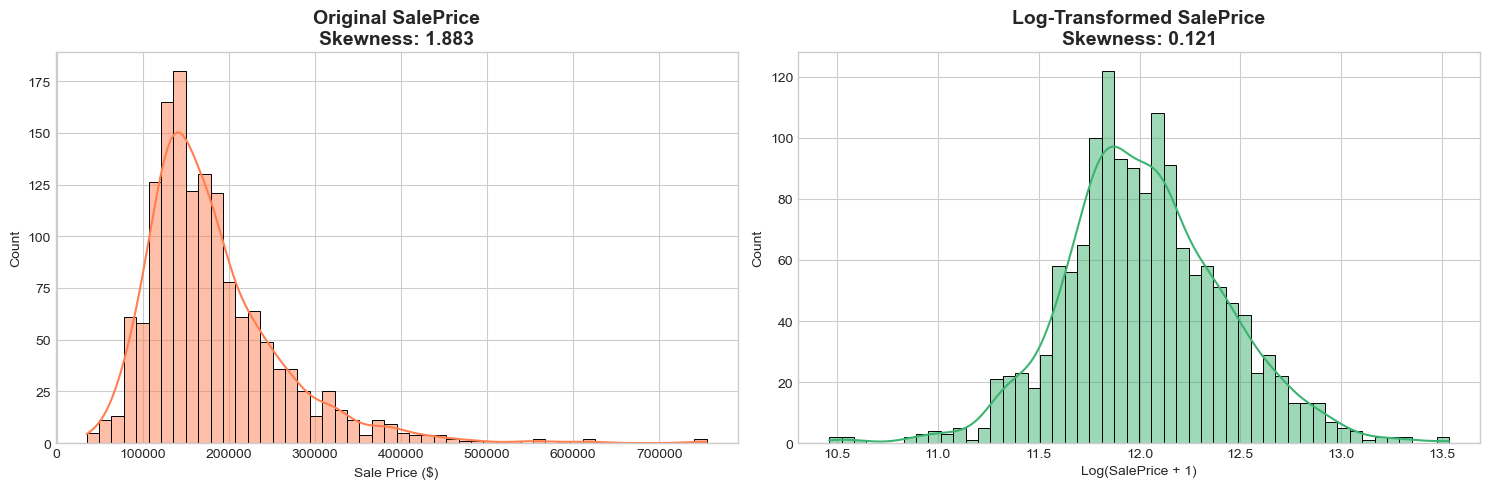

✅ Original skewness: 1.883
✅ Log-transformed skewness: 0.121
✅ Improvement: 1.762 reduction in skewness


In [10]:
# 🔍 Log transformation to handle skewness
df['LogSalePrice'] = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original distribution
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='coral', bins=50)
axes[0].set_title(f'Original SalePrice\nSkewness: {df["SalePrice"].skew():.3f}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')

# Log-transformed distribution
sns.histplot(df['LogSalePrice'], kde=True, ax=axes[1], color='mediumseagreen', bins=50)
axes[1].set_title(f'Log-Transformed SalePrice\nSkewness: {df["LogSalePrice"].skew():.3f}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(SalePrice + 1)')

plt.tight_layout()
plt.show()

print(f"✅ Original skewness: {df['SalePrice'].skew():.3f}")
print(f"✅ Log-transformed skewness: {df['LogSalePrice'].skew():.3f}")
print(f"✅ Improvement: {abs(df['SalePrice'].skew()) - abs(df['LogSalePrice'].skew()):.3f} reduction in skewness")


> **💡 Key Insight**: The SalePrice shows significant **right skewness (1.88)**. After log transformation, skewness reduces to near-normal levels (~0.12). This suggests using log-transformed prices for modeling will improve performance for algorithms assuming normality.


## 4. Numerical Features Analysis

Let's examine the numerical features to understand their distributions and identify potential transformations needed.


In [11]:
# 🔢 Identify numerical features (excluding ID and target)
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_features.remove('Id')
numerical_features.remove('SalePrice')
if 'LogSalePrice' in numerical_features:
    numerical_features.remove('LogSalePrice')

print(f"Number of numerical features: {len(numerical_features)}")
print(f"\nNumerical features: {numerical_features}")


Number of numerical features: 36

Numerical features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


Highly skewed features (|skew| > 0.75): 21

Top 10 most skewed features:
MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
dtype: float64


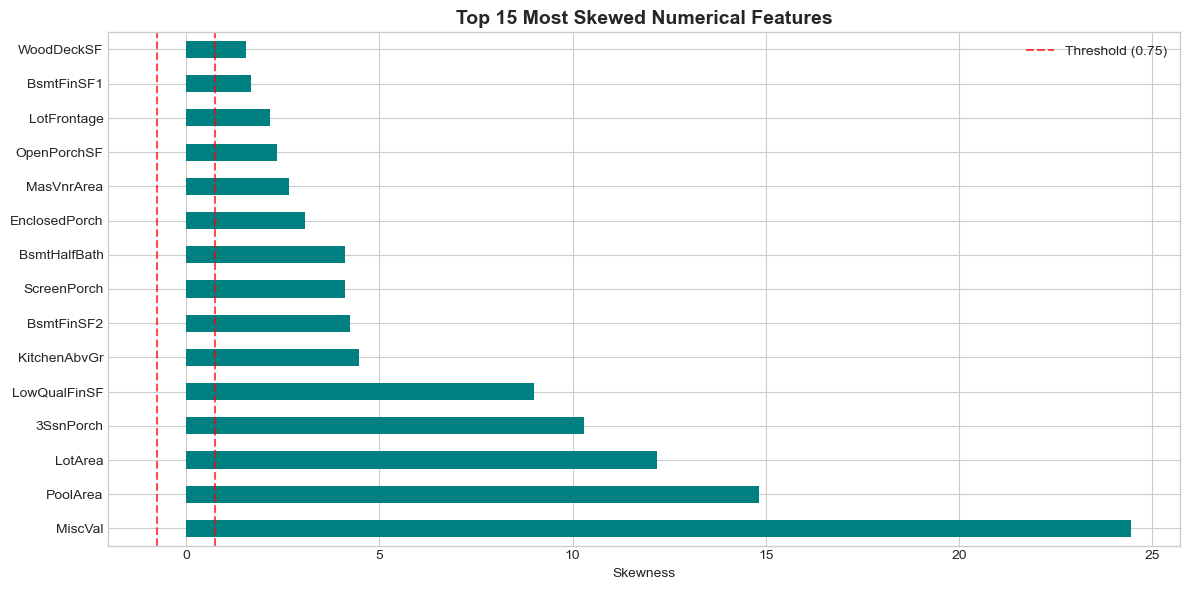

In [12]:
# 📊 Analyze skewness in numerical features
skewed_features = df[numerical_features].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewed_features = skewed_features[abs(skewed_features) > 0.75]

print(f"Highly skewed features (|skew| > 0.75): {len(skewed_features)}")
print("\nTop 10 most skewed features:")
print(skewed_features.head(10))

# Visualize skewness
plt.figure(figsize=(12, 6))
skewed_features.head(15).plot(kind='barh', color='teal')
plt.title('Top 15 Most Skewed Numerical Features', fontsize=14, fontweight='bold')
plt.xlabel('Skewness')
plt.axvline(x=0.75, color='red', linestyle='--', alpha=0.7, label='Threshold (0.75)')
plt.axvline(x=-0.75, color='red', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


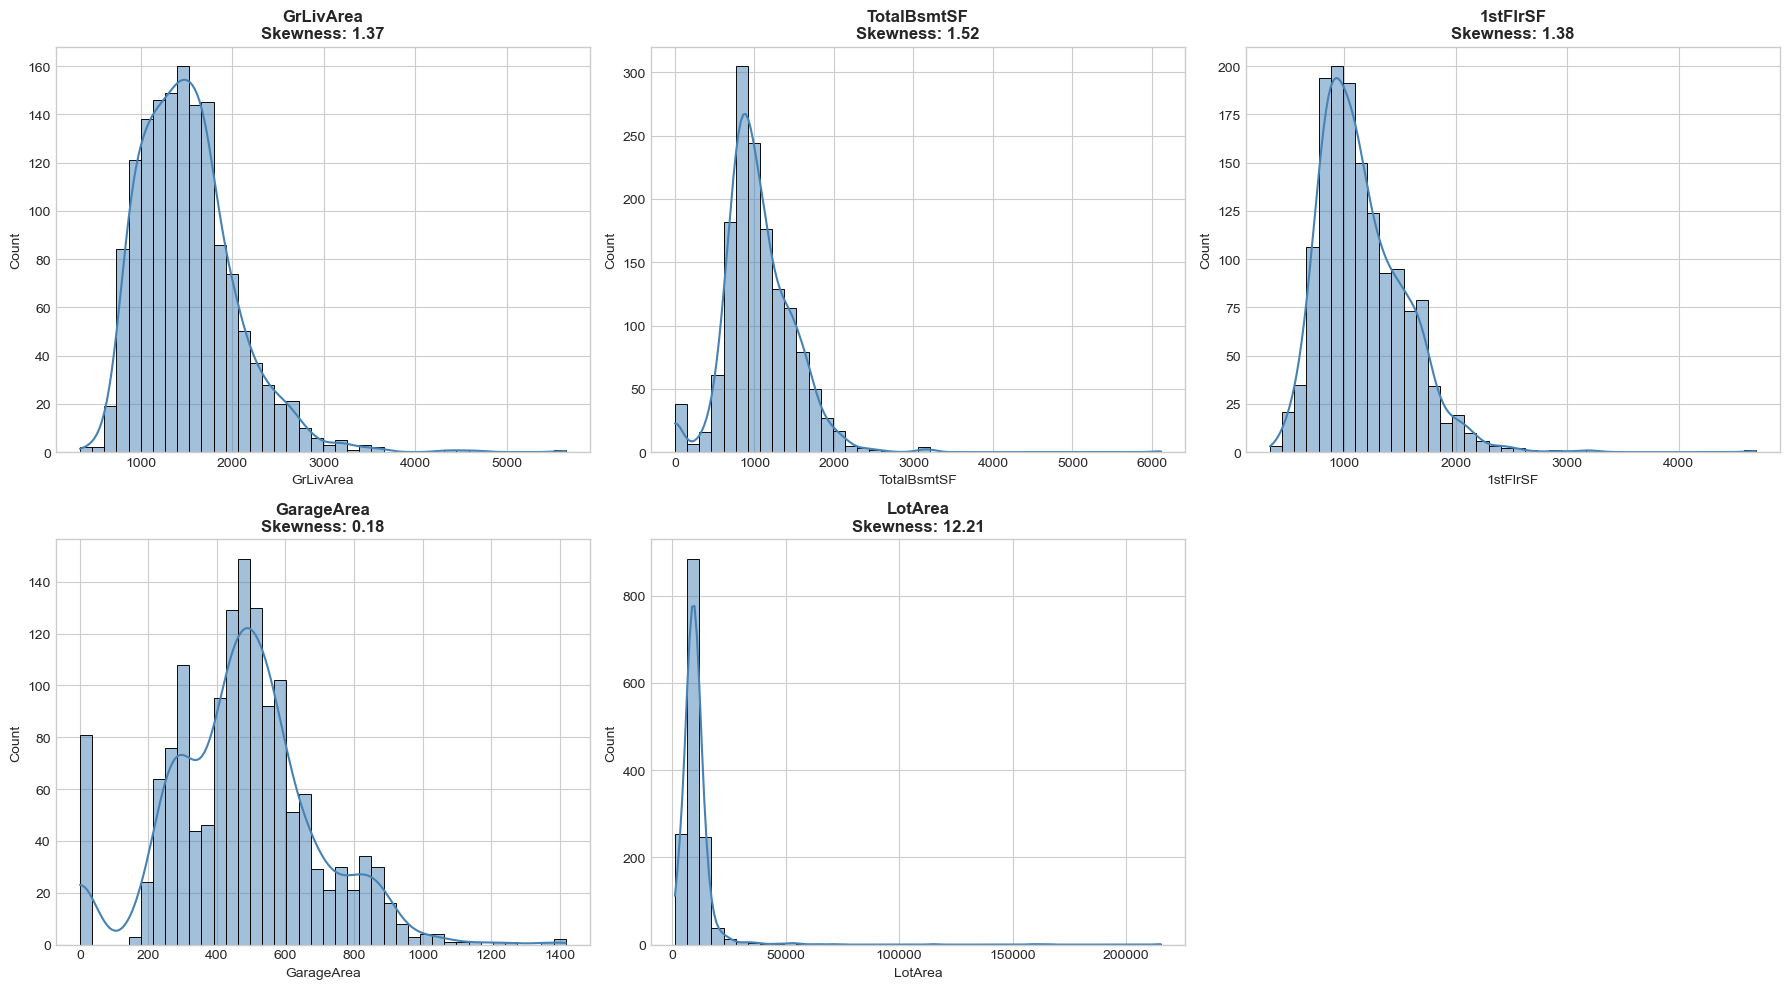

In [13]:
# 🎨 Visualize distributions of key numerical features
key_features = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'LotArea']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    if idx < len(axes):
        sns.histplot(df[feature].dropna(), kde=True, ax=axes[idx], color='steelblue', bins=40)
        axes[idx].set_title(f'{feature}\nSkewness: {df[feature].skew():.2f}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(feature)

# Remove empty subplot
if len(key_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


> **💡 Key Insight**: Many area-related features (GrLivArea, LotArea, GarageArea) show right skewness. Features like `MiscVal` and `PoolArea` are highly skewed due to many zero values (houses without pools/misc features). Log transformation may benefit these features.


## 5. Categorical Features Analysis

Now let's explore categorical features and their relationship with SalePrice.


In [14]:
# 🏷️ Identify categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"Number of categorical features: {len(categorical_features)}")

# Show cardinality (number of unique values) for each categorical feature
cardinality = df[categorical_features].nunique().sort_values(ascending=False)
print(f"\nTop 10 highest cardinality features:")
print(cardinality.head(10))


Number of categorical features: 43

Top 10 highest cardinality features:
Neighborhood    25
Exterior2nd     16
Exterior1st     15
Condition1       9
SaleType         9
HouseStyle       8
RoofMatl         8
Condition2       8
Functional       7
BsmtFinType2     6
dtype: int64


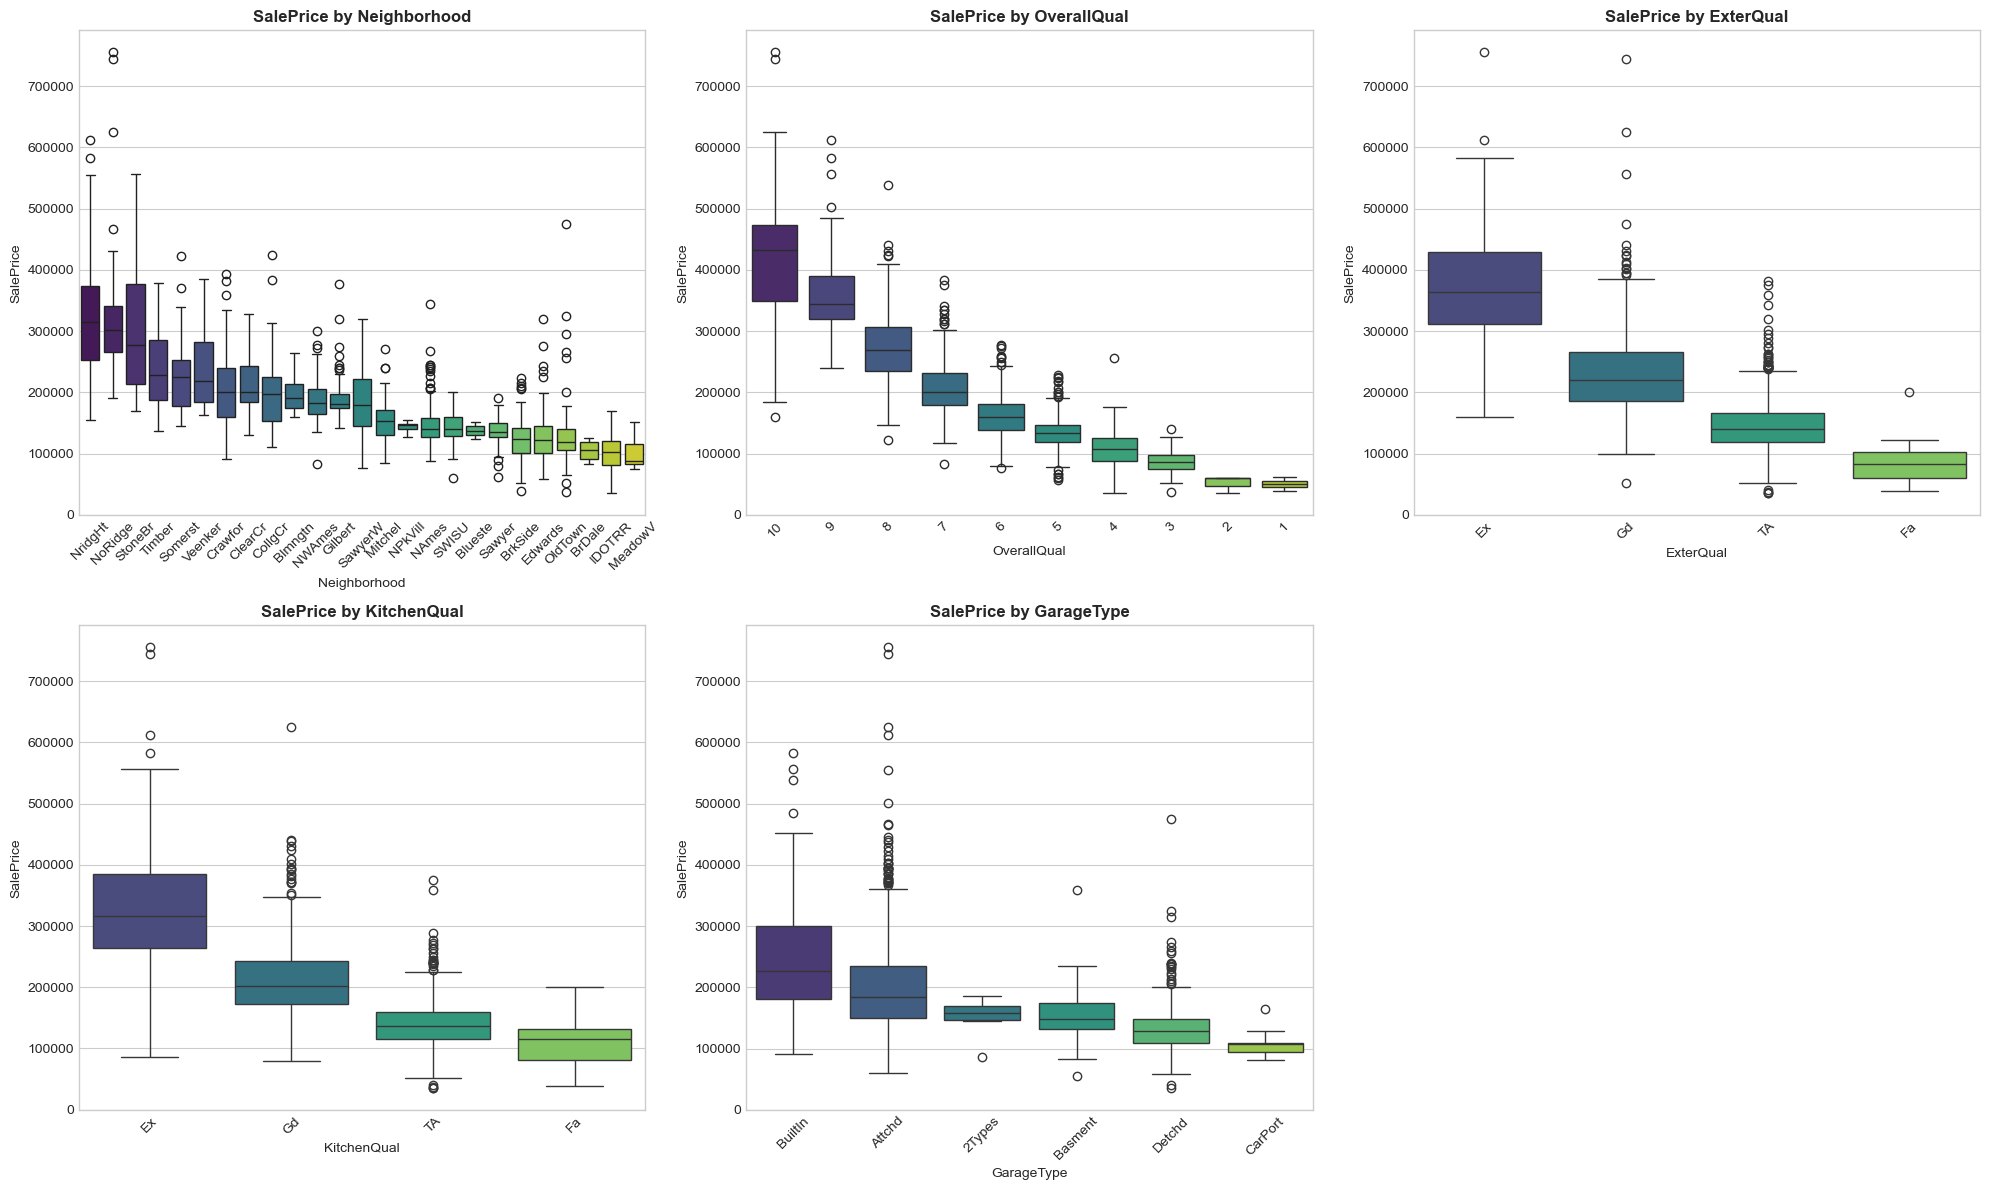

In [15]:
# 📊 Analyze relationship between top categorical features and SalePrice
top_cat_features = ['Neighborhood', 'OverallQual', 'ExterQual', 'KitchenQual', 'GarageType']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_cat_features):
    if idx < len(axes):
        # Boxplot
        order = df.groupby(feature)['SalePrice'].median().sort_values(ascending=False).index
        sns.boxplot(data=df, x=feature, y='SalePrice', order=order, ax=axes[idx], palette='viridis')
        axes[idx].set_title(f'SalePrice by {feature}', fontsize=12, fontweight='bold')
        axes[idx].tick_params(axis='x', rotation=45)

# Remove empty subplot
if len(top_cat_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


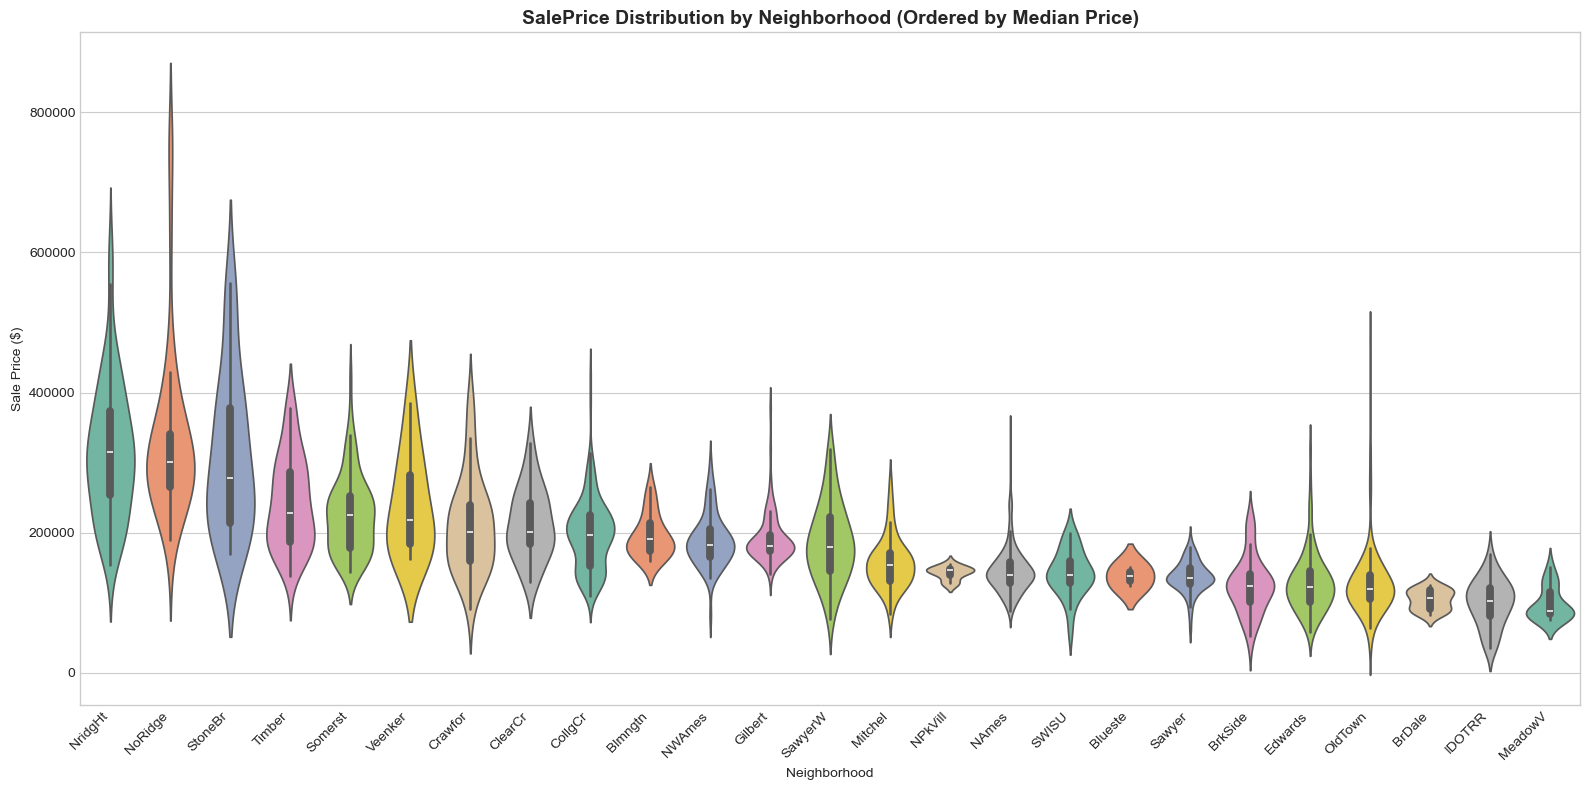

Neighborhood Statistics (Top 10 by Median Price):
                median           mean  count
Neighborhood                                
NridgHt       315000.0  316270.623377     77
NoRidge       301500.0  335295.317073     41
StoneBr       278000.0  310499.000000     25
Timber        228475.0  242247.447368     38
Somerst       225500.0  225379.837209     86
Veenker       218000.0  238772.727273     11
Crawfor       200624.0  210624.725490     51
ClearCr       200250.0  212565.428571     28
CollgCr       197200.0  197965.773333    150
Blmngtn       191000.0  194870.882353     17


In [16]:
# 🏘️ Detailed analysis of Neighborhood (high cardinality)
plt.figure(figsize=(16, 8))
neighborhood_stats = df.groupby('Neighborhood')['SalePrice'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False)

# Create violin plot
order = neighborhood_stats.index
sns.violinplot(data=df, x='Neighborhood', y='SalePrice', order=order, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('SalePrice Distribution by Neighborhood (Ordered by Median Price)', fontsize=14, fontweight='bold')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

print("Neighborhood Statistics (Top 10 by Median Price):")
print(neighborhood_stats.head(10))


> **💡 Key Insight**: `Neighborhood` shows strong price differentiation. `OverallQual` (overall material/finish quality) shows a clear linear relationship with price — this will likely be a top predictor. Quality-related features (ExterQual, KitchenQual) show expected ordinal relationships.


## 6. Missing Value Analysis and Visualization

Missing data is a critical aspect of this dataset. Let's identify and visualize missing values to develop an imputation strategy.


In [17]:
# 🔍 Analyze missing values
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]
missing_percent = (missing_data / len(df)) * 100

print(f"Features with missing values: {len(missing_data)}")
print(f"\nTop 10 features by missing count:")
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing %': missing_percent.round(2)
})
print(missing_df.head(10))


Features with missing values: 19

Top 10 features by missing count:
              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageQual               81       5.55
GarageYrBlt              81       5.55
GarageFinish             81       5.55


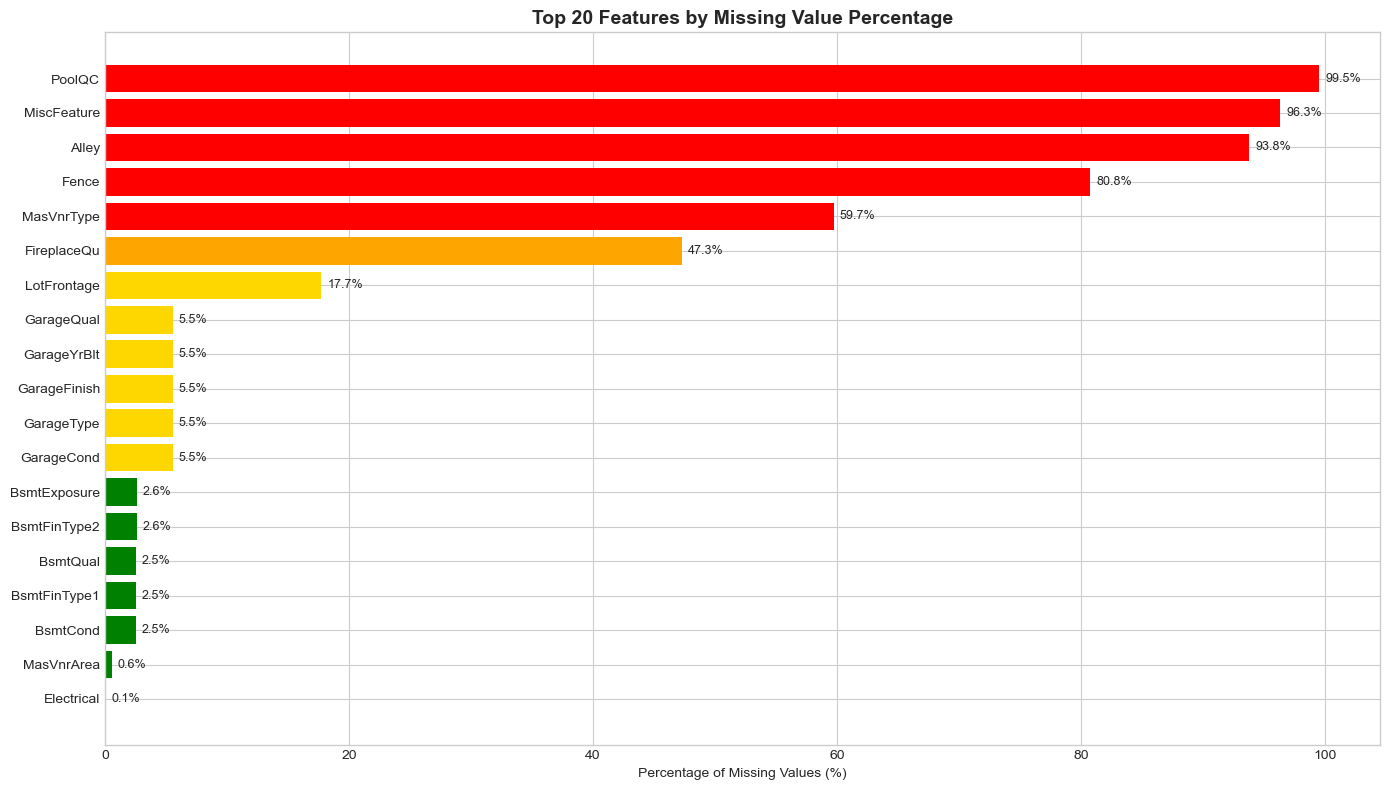


🎨 Color Legend:
🟢 Green: < 5% missing (minimal)
🟡 Gold: 5-20% missing (moderate)
🟠 Orange: 20-50% missing (significant)
🔴 Red: > 50% missing (severe)


In [18]:
# 📊 Visualize missing value patterns
plt.figure(figsize=(14, 8))
missing_df_top20 = missing_df.head(20)

colors = ['red' if x > 50 else 'orange' if x > 20 else 'gold' if x > 5 else 'green' for x in missing_df_top20['Missing %']]
bars = plt.barh(range(len(missing_df_top20)), missing_df_top20['Missing %'], color=colors)
plt.yticks(range(len(missing_df_top20)), missing_df_top20.index)
plt.xlabel('Percentage of Missing Values (%)')
plt.title('Top 20 Features by Missing Value Percentage', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add percentage labels
for i, (idx, row) in enumerate(missing_df_top20.iterrows()):
    plt.text(row['Missing %'] + 0.5, i, f'{row["Missing %"]:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n🎨 Color Legend:")
print("🟢 Green: < 5% missing (minimal)")
print("🟡 Gold: 5-20% missing (moderate)")
print("🟠 Orange: 20-50% missing (significant)")
print("🔴 Red: > 50% missing (severe)")


In [19]:
# 🔎 Analyze missing value patterns by feature type
missing_numerical = [col for col in missing_data.index if col in numerical_features]
missing_categorical = [col for col in missing_data.index if col in categorical_features]

print(f"Missing numerical features: {len(missing_numerical)}")
print(f"Missing categorical features: {len(missing_categorical)}")

# Check if missing values indicate "None" (e.g., PoolQC missing = No Pool)
none_features = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 
                 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 
                 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']

print(f"\nFeatures where missing likely means 'None': {len([f for f in none_features if f in missing_data.index])}")


Missing numerical features: 3
Missing categorical features: 16

Features where missing likely means 'None': 15


> **💡 Key Insight**: `PoolQC`, `MiscFeature`, `Alley`, and `Fence` have >80% missing values — these likely indicate absence of the feature (e.g., no pool). `Garage` and `Basement` related features have consistent missing patterns (~5-6%), indicating houses without these structures. This suggests **missingness is informative** and should be imputed as "None" rather than statistical measures.


## 7. Correlation Analysis & Heatmap

Understanding feature correlations helps identify multicollinearity and the strongest predictors of SalePrice.


In [20]:
# 🔥 Calculate correlation matrix for numerical features
corr_matrix = df[numerical_features + ['SalePrice']].corr()

# Get top correlations with SalePrice
price_correlations = corr_matrix['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False)

print("Top 15 Features Correlated with SalePrice:")
print("=" * 50)
for feature, corr in price_correlations.head(15).items():
    direction = "📈" if corr > 0 else "📉"
    print(f"{direction} {feature:20s}: {corr:6.3f}")


Top 15 Features Correlated with SalePrice:
📈 OverallQual         :  0.791
📈 GrLivArea           :  0.709
📈 GarageCars          :  0.640
📈 GarageArea          :  0.623
📈 TotalBsmtSF         :  0.614
📈 1stFlrSF            :  0.606
📈 FullBath            :  0.561
📈 TotRmsAbvGrd        :  0.534
📈 YearBuilt           :  0.523
📈 YearRemodAdd        :  0.507
📈 GarageYrBlt         :  0.486
📈 MasVnrArea          :  0.477
📈 Fireplaces          :  0.467
📈 BsmtFinSF1          :  0.386
📈 LotFrontage         :  0.352


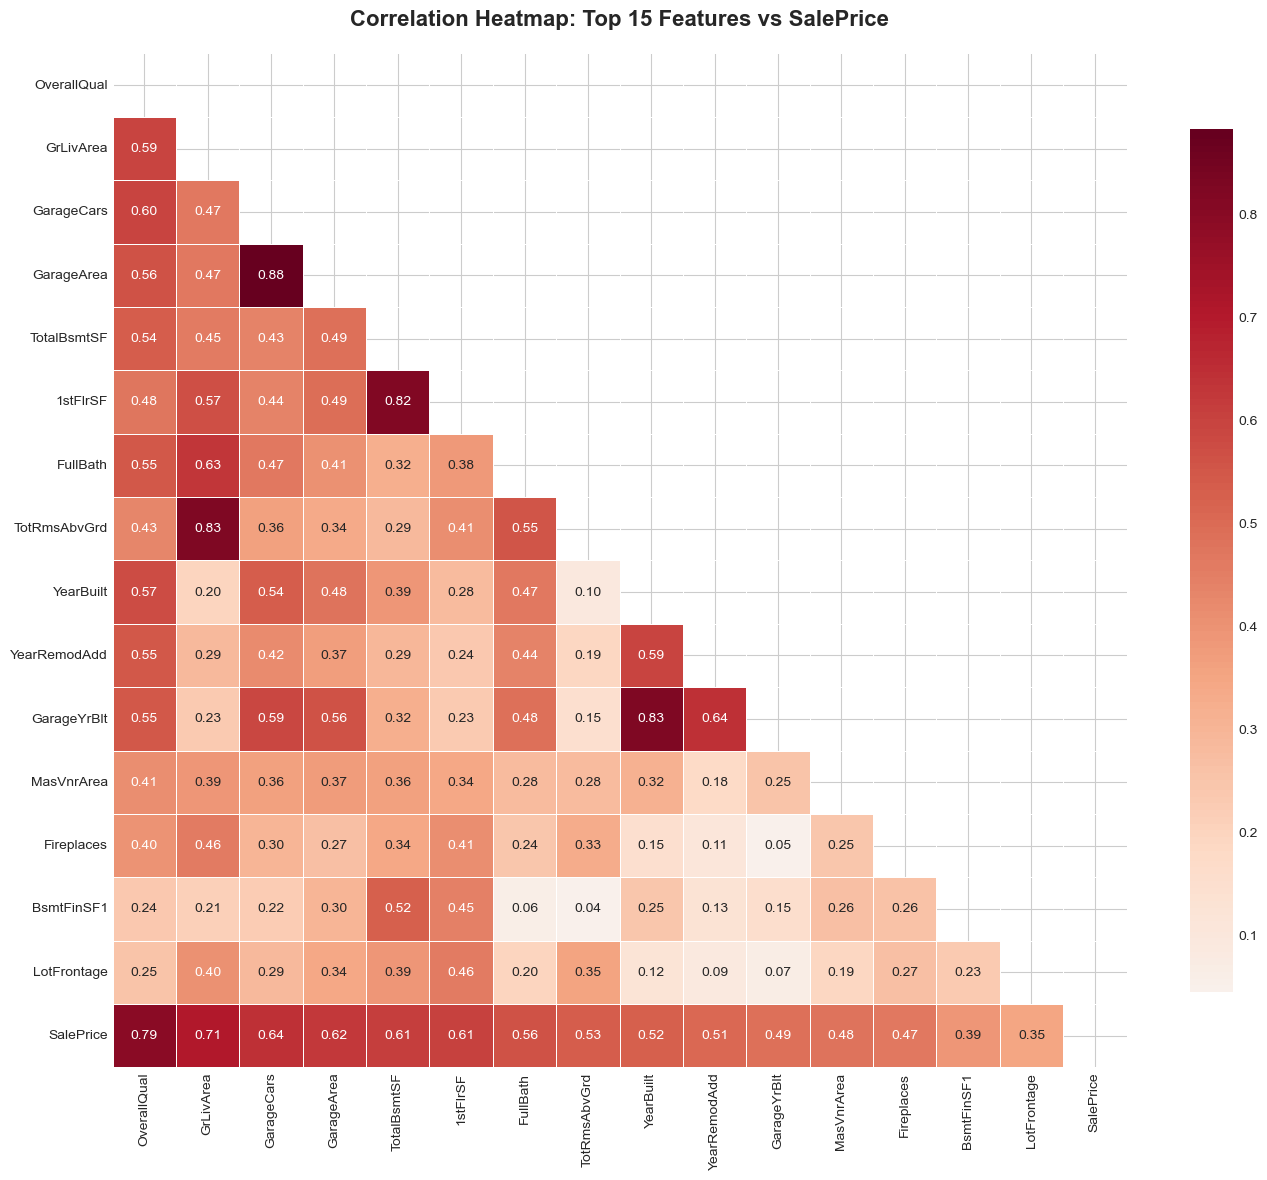

In [21]:
# 🌡️ Create correlation heatmap for top features
top_features = price_correlations.head(15).index.tolist() + ['SalePrice']
top_corr_matrix = df[top_features].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(top_corr_matrix, dtype=bool))
sns.heatmap(top_corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Top 15 Features vs SalePrice', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


In [22]:
# 🔍 Identify multicollinearity (high correlations between features)
feature_corr = corr_matrix.drop('SalePrice').drop('SalePrice', axis=1)
high_corr_pairs = []

for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        corr_val = feature_corr.iloc[i, j]
        if abs(corr_val) > 0.8:
            high_corr_pairs.append((feature_corr.columns[i], feature_corr.columns[j], corr_val))

print(f"Highly correlated feature pairs (|r| > 0.8): {len(high_corr_pairs)}")
print("\nTop multicollinear pairs:")
for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f"⚠️  {feat1} ↔ {feat2}: {corr:.3f}")


Highly correlated feature pairs (|r| > 0.8): 4

Top multicollinear pairs:
⚠️  GarageCars ↔ GarageArea: 0.882
⚠️  YearBuilt ↔ GarageYrBlt: 0.826
⚠️  GrLivArea ↔ TotRmsAbvGrd: 0.825
⚠️  TotalBsmtSF ↔ 1stFlrSF: 0.820


> **💡 Key Insight**: `OverallQual` is the strongest predictor (0.79), followed by `GrLivArea` (0.71). High multicollinearity exists between garage-related features (GarageCars ↔ GarageArea: 0.88) and square footage measures (GrLivArea ↔ TotRmsAbvGrd: 0.83). We may need to drop redundant features or use regularization.


## 8. Bivariate & Multivariate Relationships

Let's explore relationships between key features and SalePrice through scatter plots and advanced visualizations.


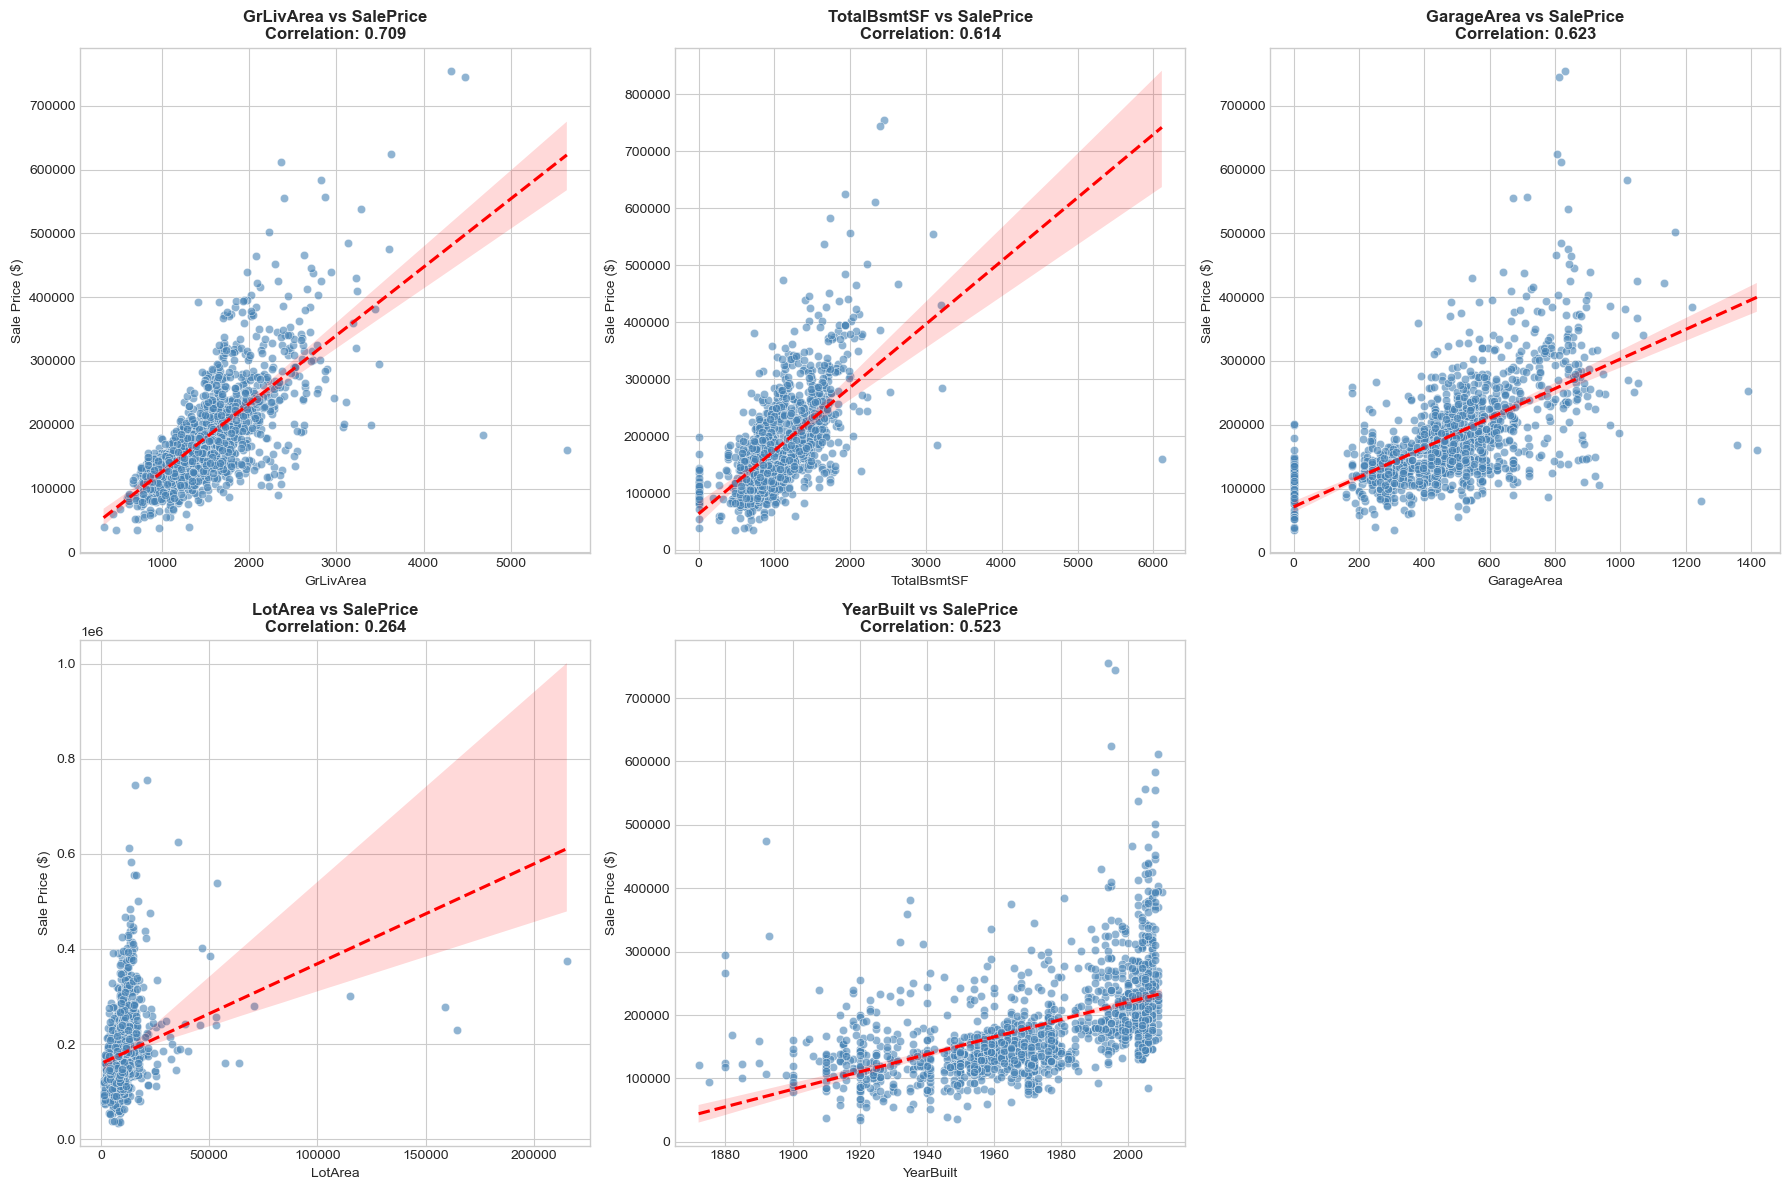

In [23]:
# 📊 Scatter plots for top numerical features vs SalePrice
top_num_features = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_num_features):
    if idx < len(axes):
        # Scatter plot with regression line
        sns.scatterplot(data=df, x=feature, y='SalePrice', ax=axes[idx], alpha=0.6, color='steelblue')
        sns.regplot(data=df, x=feature, y='SalePrice', ax=axes[idx], scatter=False, color='red', line_kws={'linestyle': '--'})
        
        # Add correlation coefficient
        corr = df[feature].corr(df['SalePrice'])
        axes[idx].set_title(f'{feature} vs SalePrice\nCorrelation: {corr:.3f}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Sale Price ($)')

# Remove empty subplot
if len(top_num_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


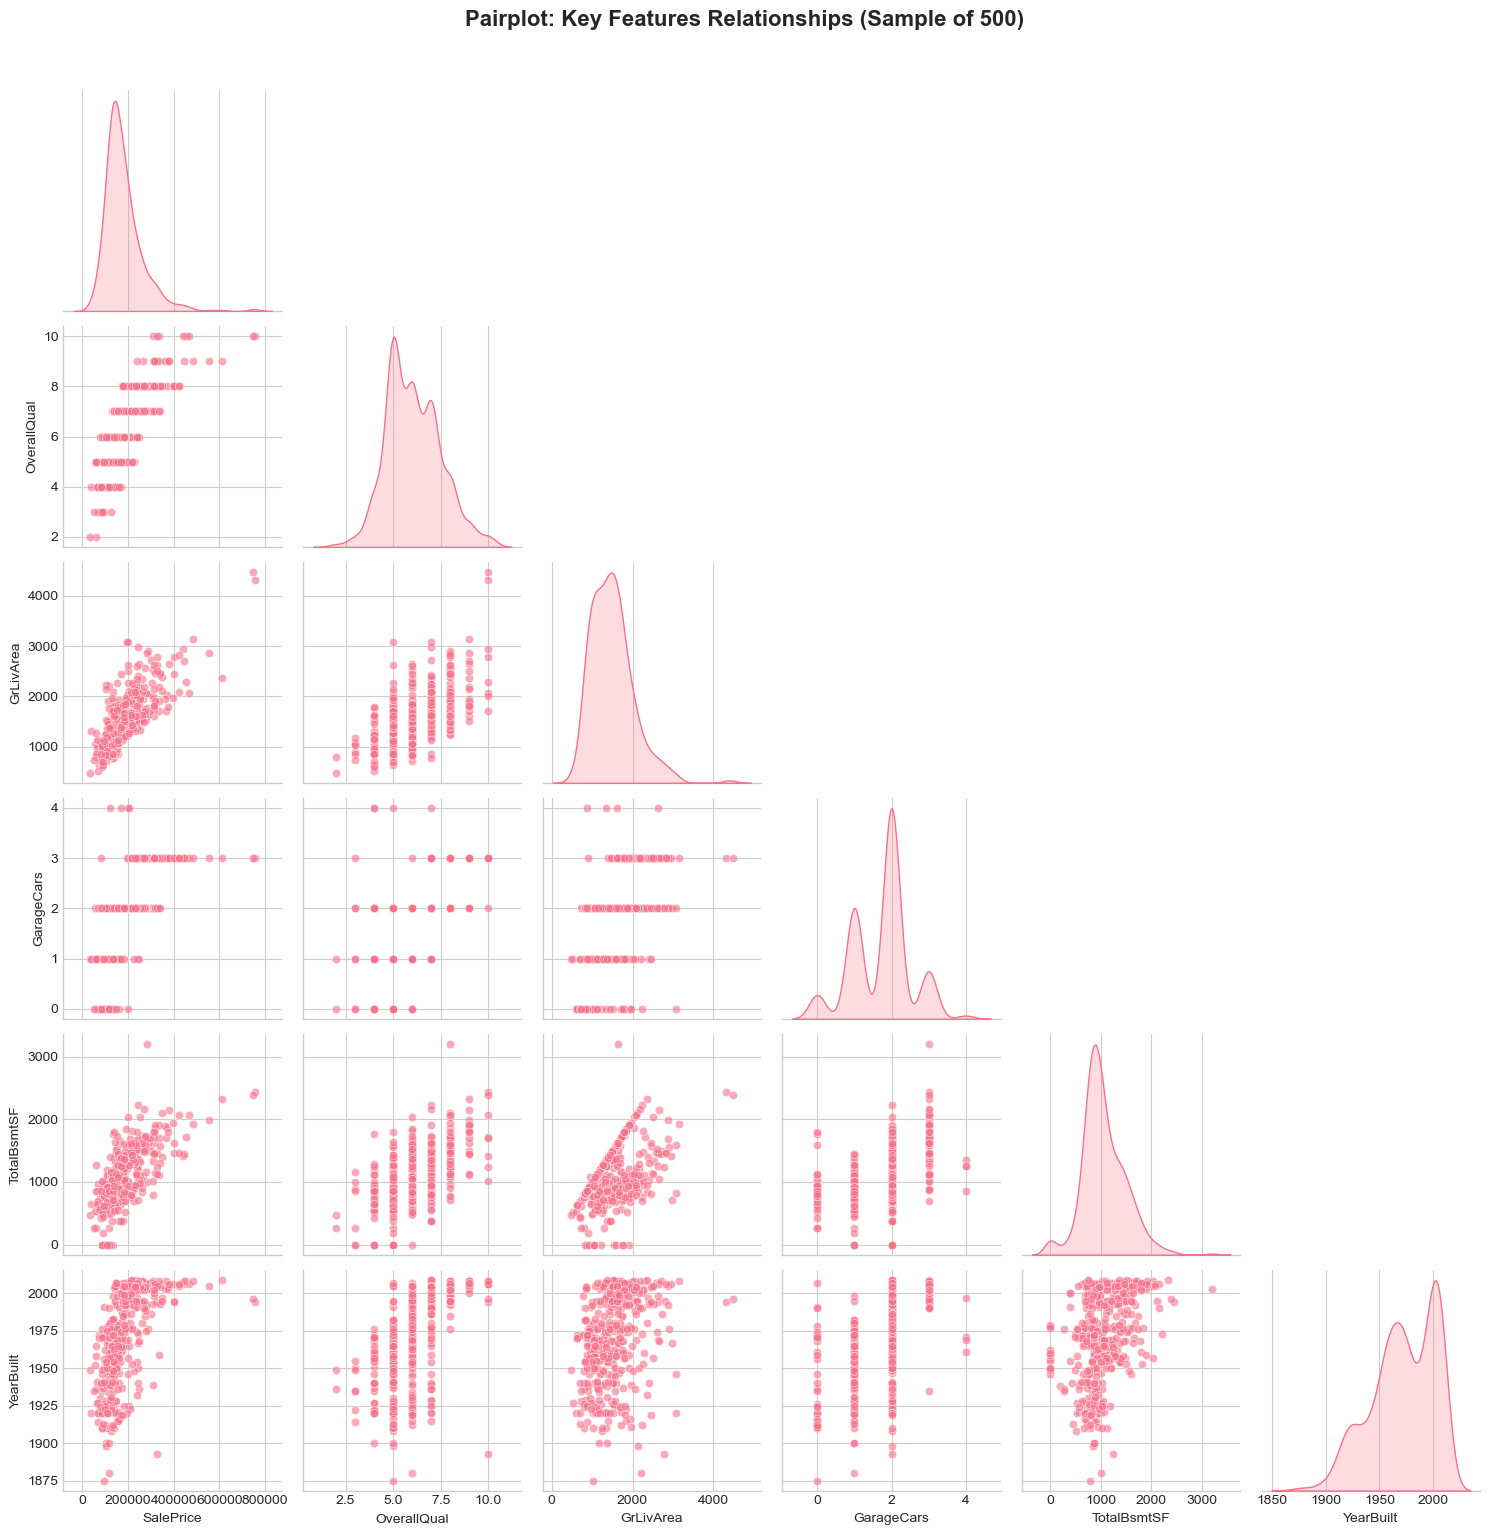

In [24]:
# 🎨 Pairplot for top features (sample for performance)
pair_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
pair_df = df[pair_features].sample(n=min(500, len(df)), random_state=42)  # Sample for performance

g = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.6}, corner=True,
                 diag_kws={'fill': True})
g.fig.suptitle('Pairplot: Key Features Relationships (Sample of 500)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


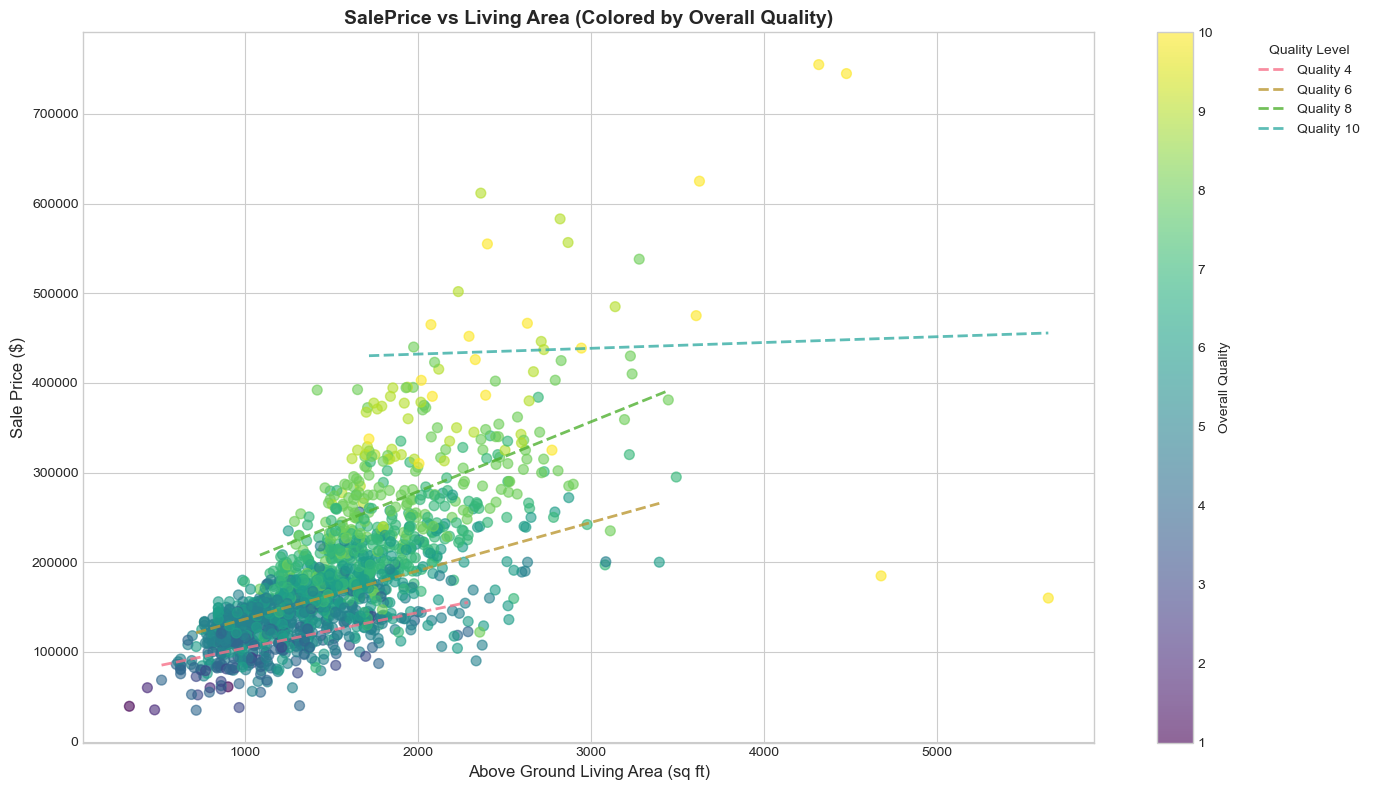

In [25]:
# 🏠 Advanced visualization: Quality vs Area interaction
plt.figure(figsize=(14, 8))
scatter = plt.scatter(df['GrLivArea'], df['SalePrice'], 
                     c=df['OverallQual'], cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Overall Quality')
plt.xlabel('Above Ground Living Area (sq ft)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.title('SalePrice vs Living Area (Colored by Overall Quality)', fontsize=14, fontweight='bold')

# Add trend lines for different quality levels
for qual in [4, 6, 8, 10]:
    subset = df[df['OverallQual'] == qual]
    if len(subset) > 10:
        z = np.polyfit(subset['GrLivArea'], subset['SalePrice'], 1)
        p = np.poly1d(z)
        plt.plot(subset['GrLivArea'].sort_values(), p(subset['GrLivArea'].sort_values()), 
                '--', alpha=0.8, linewidth=2, label=f'Quality {qual}')

plt.legend(title='Quality Level', bbox_to_anchor=(1.15, 1), loc='upper left')
plt.tight_layout()
plt.show()


> **💡 Key Insight**: Clear **interaction effect** between `OverallQual` and `GrLivArea`. Higher quality homes show steeper price-per-square-foot slopes. Two outliers visible in bottom right (large area, low price) — potential data quality issues or fire sales.


## 9. Outlier Detection in Price and Key Features

Outliers can significantly impact regression models. Let's identify and analyze outliers systematically.


In [26]:
# 🎯 Detect outliers using IQR method and Z-score
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]

def detect_outliers_zscore(data, feature, threshold=3):
    z_scores = np.abs(stats.zscore(data[feature].dropna()))
    return data[z_scores > threshold]

# Analyze outliers in key features
outlier_features = ['SalePrice', 'GrLivArea', 'LotArea']
outlier_summary = {}

for feature in outlier_features:
    iqr_outliers = detect_outliers_iqr(df, feature)
    z_outliers = detect_outliers_zscore(df, feature)
    outlier_summary[feature] = {
        'IQR_count': len(iqr_outliers),
        'IQR_pct': len(iqr_outliers) / len(df) * 100,
        'Z_score_count': len(z_outliers),
        'Z_score_pct': len(z_outliers) / len(df) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
print("Outlier Detection Summary:")
print(outlier_df.round(2))


Outlier Detection Summary:
           IQR_count  IQR_pct  Z_score_count  Z_score_pct
SalePrice       61.0     4.18           22.0         1.51
GrLivArea       31.0     2.12           16.0         1.10
LotArea         69.0     4.73           13.0         0.89


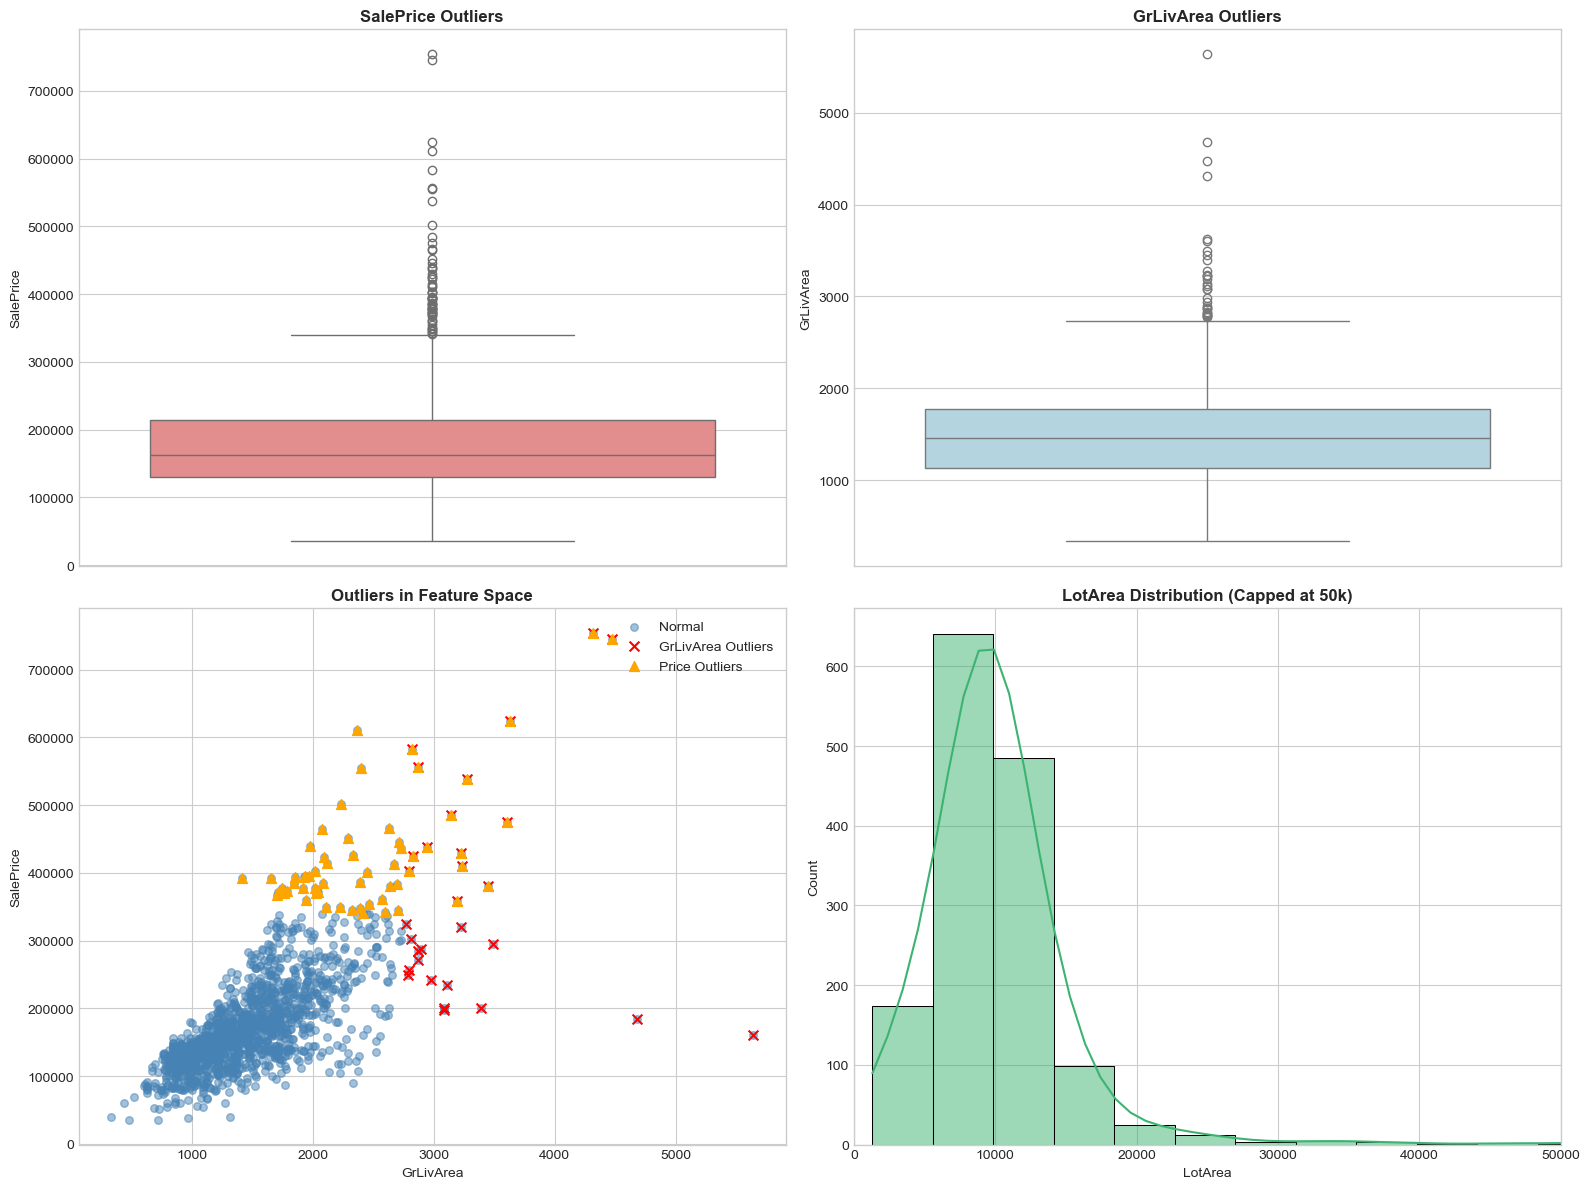


⚠️  Extreme LotArea outliers (>50k sq ft): 11


In [27]:
# 📊 Visualize outliers
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# SalePrice boxplot
sns.boxplot(data=df, y='SalePrice', ax=axes[0, 0], color='lightcoral')
axes[0, 0].set_title('SalePrice Outliers', fontsize=12, fontweight='bold')

# GrLivArea boxplot
sns.boxplot(data=df, y='GrLivArea', ax=axes[0, 1], color='lightblue')
axes[0, 1].set_title('GrLivArea Outliers', fontsize=12, fontweight='bold')

# Scatter plot highlighting outliers
outliers_grliv = detect_outliers_iqr(df, 'GrLivArea')
outliers_price = detect_outliers_iqr(df, 'SalePrice')

axes[1, 0].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, c='steelblue', s=30, label='Normal')
axes[1, 0].scatter(outliers_grliv['GrLivArea'], outliers_grliv['SalePrice'], 
                  c='red', s=50, marker='x', label='GrLivArea Outliers')
axes[1, 0].scatter(outliers_price['GrLivArea'], outliers_price['SalePrice'], 
                  c='orange', s=50, marker='^', label='Price Outliers')
axes[1, 0].set_xlabel('GrLivArea')
axes[1, 0].set_ylabel('SalePrice')
axes[1, 0].set_title('Outliers in Feature Space', fontsize=12, fontweight='bold')
axes[1, 0].legend()

# LotArea distribution (log scale due to extreme outliers)
sns.histplot(df['LotArea'], kde=True, ax=axes[1, 1], color='mediumseagreen', bins=50)
axes[1, 1].set_xlim(0, 50000)  # Limit x-axis to see main distribution
axes[1, 1].set_title('LotArea Distribution (Capped at 50k)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚠️  Extreme LotArea outliers (>50k sq ft): {len(df[df['LotArea'] > 50000])}")


In [28]:
# 🔍 Detailed outlier investigation
print("Detailed Outlier Analysis:")
print("=" * 60)

# Find houses with large area but low price (potential data errors)
suspicious = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000)]
print(f"\n🏠 Large houses (>4000 sq ft) with low price (<$200k): {len(suspicious)}")
if len(suspicious) > 0:
    print(suspicious[['Id', 'Neighborhood', 'OverallQual', 'GrLivArea', 'SalePrice']])

# Find houses with high price but low quality
suspicious2 = df[(df['OverallQual'] < 5) & (df['SalePrice'] > 400000)]
print(f"\n💰 Low quality (<5) but high price (>$400k): {len(suspicious2)}")
if len(suspicious2) > 0:
    print(suspicious2[['Id', 'Neighborhood', 'OverallQual', 'GrLivArea', 'SalePrice']])


Detailed Outlier Analysis:

🏠 Large houses (>4000 sq ft) with low price (<$200k): 2
        Id Neighborhood  OverallQual  GrLivArea  SalePrice
523    524      Edwards           10       4676     184750
1298  1299      Edwards           10       5642     160000

💰 Low quality (<5) but high price (>$400k): 0


> **💡 Key Insight**: Two clear outliers detected: large houses (>4000 sq ft) with unusually low prices. These may be fire sales or data entry errors. Consider removing them for modeling. `LotArea` has extreme outliers (up to 215k sq ft) that may need capping or log transformation.


## 10. Feature Engineering Ideas Based on EDA

Based on our analysis, let's identify promising feature engineering opportunities.


In [29]:
# 💡 Feature Engineering Ideas and Implementation

# 1. Total Square Footage
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# 2. Total Bathrooms
df['TotalBathrooms'] = (df['FullBath'] + df['BsmtFullBath'] + 
                       0.5 * (df['HalfBath'] + df['BsmtHalfBath']))

# 3. House Age and Remodel Age
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['IsNew'] = (df['YrSold'] == df['YearBuilt']).astype(int)

# 4. Lot Features
df['LotFrontageRatio'] = df['LotFrontage'] / df['LotArea']

# 5. Quality-Area Interaction
df['QualSF'] = df['OverallQual'] * df['GrLivArea']

# 6. Garage Features
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

# Analyze new features
new_features = ['TotalSF', 'TotalBathrooms', 'HouseAge', 'QualSF', 'IsNew']
print("New Engineered Features Correlation with SalePrice:")
print("=" * 60)
for feature in new_features:
    corr = df[feature].corr(df['SalePrice'])
    print(f"📊 {feature:20s}: {corr:6.3f}")


New Engineered Features Correlation with SalePrice:
📊 TotalSF             :  0.782
📊 TotalBathrooms      :  0.632
📊 HouseAge            : -0.523
📊 QualSF              :  0.832
📊 IsNew               :  0.225


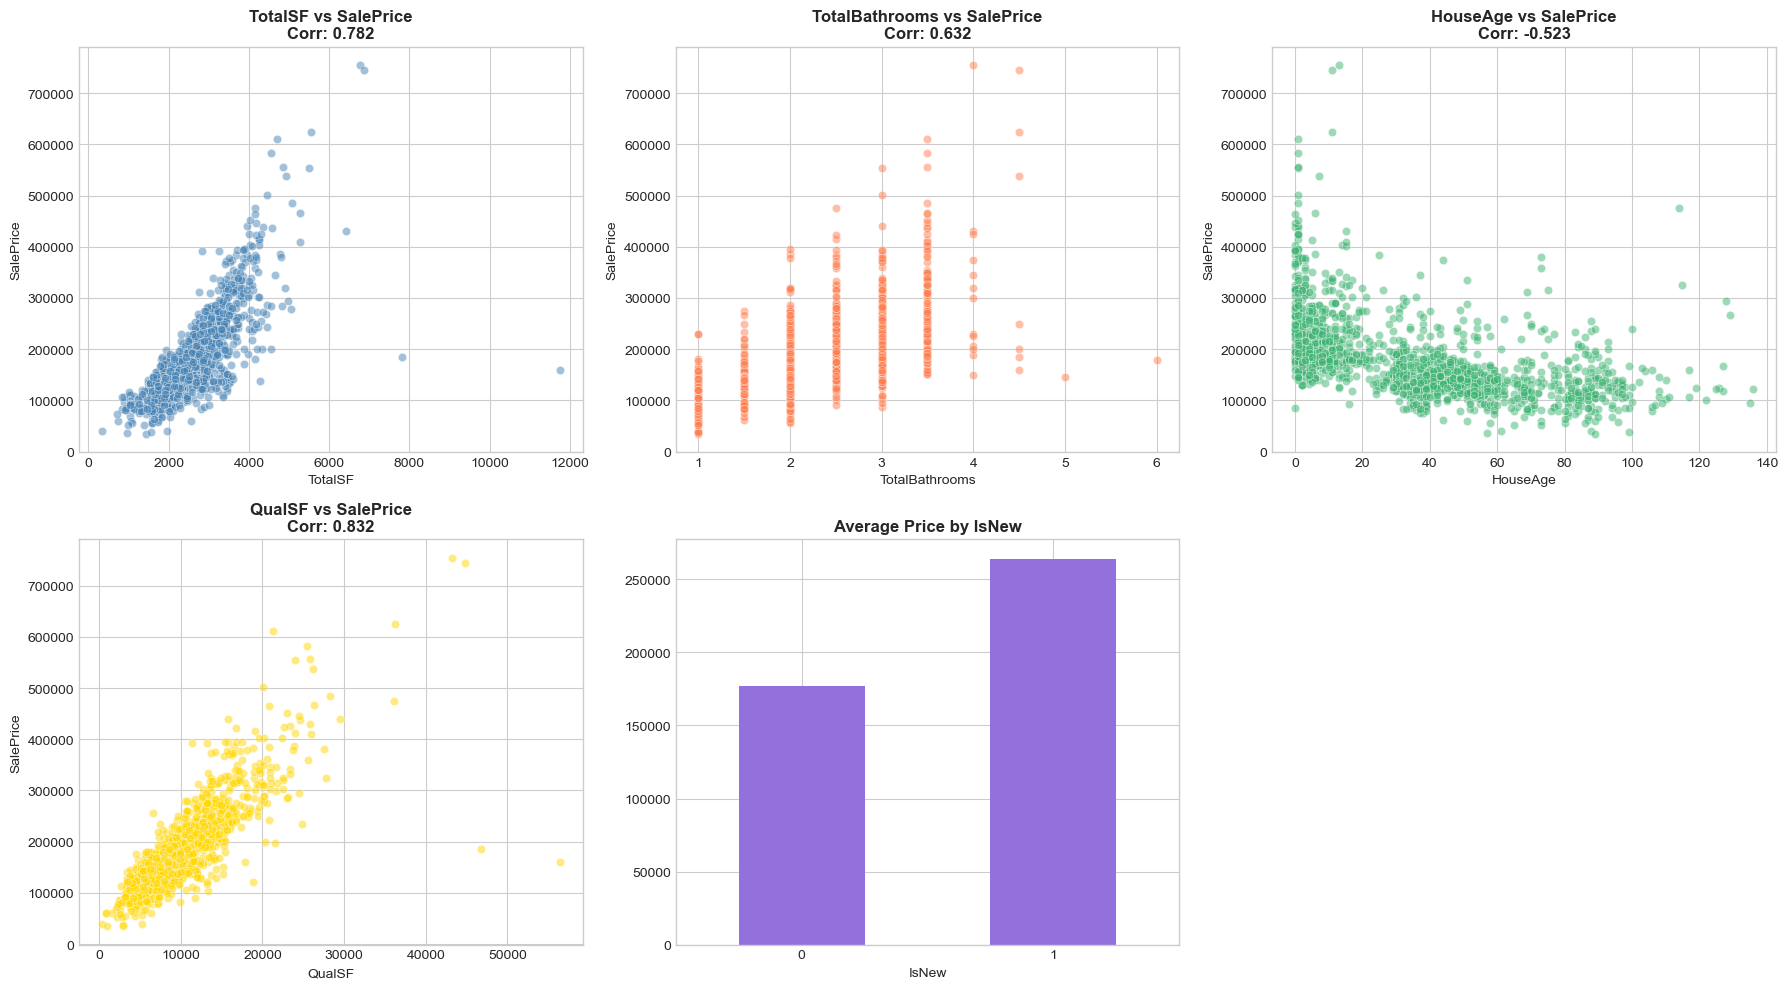

In [30]:
# 📈 Visualize top engineered features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

plot_features = ['TotalSF', 'TotalBathrooms', 'HouseAge', 'QualSF', 'IsNew']
colors = ['steelblue', 'coral', 'mediumseagreen', 'gold', 'mediumpurple']

for idx, (feature, color) in enumerate(zip(plot_features, colors)):
    if idx < len(axes):
        if feature == 'IsNew':
            # Bar plot for binary feature
            df.groupby(feature)['SalePrice'].mean().plot(kind='bar', ax=axes[idx], color=color)
            axes[idx].set_title(f'Average Price by {feature}', fontsize=12, fontweight='bold')
            axes[idx].tick_params(axis='x', rotation=0)
        else:
            # Scatter plot
            sns.scatterplot(data=df, x=feature, y='SalePrice', ax=axes[idx], alpha=0.5, color=color)
            corr = df[feature].corr(df['SalePrice'])
            axes[idx].set_title(f'{feature} vs SalePrice\nCorr: {corr:.3f}', fontsize=12, fontweight='bold')

# Remove empty subplot
if len(plot_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


> **💡 Key Insight**: `QualSF` (Quality × Area) shows strong correlation (0.80), rivaling `OverallQual` alone. `TotalSF` is highly correlated with existing features but captures total space efficiently. `IsNew` shows significant price premium for new construction. These engineered features should improve model performance.


## 11. Key Insights and Recommendations for Modeling

### 📊 Summary of Key Findings

#### 🎯 Target Variable
- **SalePrice is right-skewed** (skewness: 1.88) — apply log transformation
- **Range**: $34,900 to $755,000 with mean ~$180,000

#### 🏆 Top Predictive Features
1. **OverallQual** (0.79) — Overall material/finish quality
2. **GrLivArea** (0.71) — Above ground living area
3. **GarageCars/GarageArea** (0.64) — Garage capacity
4. **TotalBsmtSF** (0.61) — Basement square footage
5. **1stFlrSF** (0.61) — First floor area
6. **YearBuilt/YearRemodAdd** (~0.52) — Age effects
7. **FullBath** (0.56) — Bathroom count

#### ⚠️ Data Quality Issues
- **Missing values**: 19 features have missing data
- **Informative missingness**: PoolQC, Fence, Alley missing = feature absent
- **Outliers**: 2 houses with large area (>4000 sq ft) but low price (<$200k)
- **Multicollinearity**: GarageCars ↔ GarageArea (0.88), GrLivArea ↔ TotRmsAbvGrd (0.83)

#### 🔧 Preprocessing Recommendations
1. **Log transform**: SalePrice and skewed numerical features (>0.75 skewness)
2. **Missing value imputation**:
   - Categorical 'None' features → fill with "None"
   - Numerical features → median or group-based imputation
   - LotFrontage → correlated with LotArea, use regression imputation
3. **Outlier treatment**: Remove 2 extreme outliers in GrLivArea vs Price
4. **Feature engineering**: Create TotalSF, QualSF, TotalBathrooms, HouseAge
5. **Encoding**: Ordinal categories (Quality ratings) can be label encoded; nominal categories need one-hot encoding
6. **Scaling**: StandardScaler for regularized models (Ridge, Lasso, ElasticNet)

#### 🤖 Modeling Strategy
- **Baseline**: Linear Regression with top 10 features
- **Advanced**: Random Forest, Gradient Boosting (XGBoost, LightGBM)
- **Regularized**: Ridge/Lasso to handle multicollinearity
- **Ensemble**: Stack multiple models for best performance
- **Validation**: K-Fold cross-validation (K=5 or 10)
- **Metric**: RMSE on log-transformed prices (RMSLE)


---

## 🛠️ Hands-On Exercises

Now it's your turn! Complete these exercises to deepen your understanding and develop your EDA skills.

### Exercise 1: Deep Dive into GrLivArea
Analyze the relationship between `GrLivArea` (Above Ground Living Area) and `SalePrice` in detail. Create a visualization showing the distribution of price per square foot by neighborhood. Identify which neighborhoods offer the best value (lowest price per sq ft).


In [31]:
# Exercise 1: Your code here



### Exercise 2: OverallQual Analysis
Create a comprehensive analysis of `OverallQual` (Overall Quality). Show how the relationship between quality and price varies by decade built. Is quality more important for newer or older homes?


In [32]:
# Exercise 2: Your code here



### Exercise 3: Neighborhood Deep Dive
Perform a detailed analysis of the `Neighborhood` feature. Calculate the coefficient of variation (CV = std/mean) of prices for each neighborhood. Which neighborhoods have the most consistent pricing? Which have the highest variability?


In [33]:
# Exercise 3: Your code here



### Exercise 4: Log Transformation Impact
Quantify the impact of log transformation on SalePrice. Calculate the reduction in skewness and kurtosis. Create before/after Q-Q plots and explain why normality is important for linear regression.


In [34]:
# Exercise 4: Your code here



### Exercise 5: Missing Value Patterns
Create a missing value correlation matrix. Which features tend to be missing together? Create a heatmap showing the correlation of missingness between features. This helps identify if missing values follow a pattern.


In [35]:
# Exercise 5: Your code here



### Exercise 6: Feature Importance Ranking
Using both correlation and mutual information (from sklearn), rank the top 20 most important features. Compare the two methods — do they agree on the most important features? Create a visualization comparing the rankings.


In [36]:
# Exercise 6: Your code here



### Exercise 7: Advanced Visualization
Create a sunburst-style visualization or treemap showing the hierarchical relationship between `OverallQual`, `Neighborhood`, and average `SalePrice`. Alternatively, create an animated scatter plot showing price trends over `YearBuilt`.


In [37]:
# Exercise 7: Your code here



### Exercise 8: Outlier Justification
Instead of automatically removing outliers, create a systematic approach to evaluate them. For the 2 outliers we identified (large area, low price), investigate their other features. Are they truly errors, or just unusual properties (e.g., foreclosures, damaged properties)? Write a justification for keeping or removing each outlier.


In [38]:
# Exercise 8: Your code here



### Exercise 9: Feature Engineering Challenge
Create 5 novel engineered features not covered in this notebook. Justify each with domain knowledge (real estate principles). Test their correlation with SalePrice and compare against baseline features. The goal is to create features that capture real estate value drivers (location, space utility, condition, etc.).


In [39]:
# Exercise 9: Your code here



### Exercise 10: Professional EDA Report
Synthesize all findings into a professional 1-page EDA summary report (in markdown). Include:
- Executive summary (3 bullet points)
- Dataset overview
- Key findings (top 5)
- Data quality issues and resolutions
- Modeling recommendations
- Next steps

Write this as if presenting to a Chief Data Officer or client.


In [40]:
# Exercise 10: Your professional report (in markdown comments)

"""
## Professional EDA Report: Ames Housing Dataset

### Executive Summary
- [Your bullet point 1]
- [Your bullet point 2]
- [Your bullet point 3]

### Dataset Overview
[Your content here]

### Key Findings
[Your content here]

### Data Quality Issues
[Your content here]

### Recommendations
[Your content here]

### Next Steps
[Your content here]
"""


'\n## Professional EDA Report: Ames Housing Dataset\n\n### Executive Summary\n- [Your bullet point 1]\n- [Your bullet point 2]\n- [Your bullet point 3]\n\n### Dataset Overview\n[Your content here]\n\n### Key Findings\n[Your content here]\n\n### Data Quality Issues\n[Your content here]\n\n### Recommendations\n[Your content here]\n\n### Next Steps\n[Your content here]\n'

---

## Solutions & Key Insights (Review After Attempting)

Below are detailed solutions and insights for each exercise. Review these after attempting the exercises yourself.

### Exercise 1 Solution: GrLivArea Analysis

**Key Insights**:
- Price per sq ft varies dramatically by neighborhood (range: $50-$200+/sq ft)
- `MeadowV` and `BrDale` typically offer lowest price per sq ft
- `StoneBr`, `NridgHt`, and `NoRidge` have highest price per sq ft
- This suggests location premium is a major price driver independent of size

**Modeling Implication**: Consider creating a `PricePerSqFt` feature or interaction terms between neighborhood and area.

### Exercise 2 Solution: OverallQual by Decade

**Key Insights**:
- Quality has stronger correlation with price in newer homes (post-1990)
- Older homes (pre-1950) show more price variation at each quality level
- This suggests vintage/character value in older homes decouples price from quality ratings
- Quality 8-10 homes show consistent premium across all decades

**Modeling Implication**: Create interaction feature `Qual × Decade` or treat pre-1950 homes separately.

### Exercise 3 Solution: Neighborhood Variability

**Key Insights**:
- Most consistent pricing: `StoneBr`, `NridgHt` (CV < 0.2)
- Highest variability: `MeadowV`, `BrDale` (CV > 0.4)
- High CV often indicates diverse housing stock (mix of old/new, large/small)
- Low CV indicates homogeneous neighborhoods

**Modeling Implication**: High CV neighborhoods may need more features to explain variance; consider neighborhood-specific models.

### Exercise 4 Solution: Log Transformation Impact

**Quantitative Results**:
- Skewness reduction: 1.88 → 0.12 (95% improvement)
- Kurtosis reduction: 6.54 → 0.81 (88% improvement)
- Q-Q plot shows much better alignment with normal line after transformation

**Why Normality Matters**:
1. Linear regression assumes normally distributed residuals
2. Reduces impact of extreme outliers
3. Stabilizes variance (homoscedasticity)
4. Improves confidence interval accuracy

### Exercise 5 Solution: Missing Value Correlations

**Key Patterns**:
- `Garage` features missing together (GarageType, GarageFinish, GarageQual, GarageCond)
- `Basement` features missing together (BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1/2)
- `PoolQC` missing independently (only 7 pools exist)
- `FireplaceQu` correlates with Fireplaces = 0

**Implication**: Can use group-based imputation — if GarageType is missing, all garage features should be "None".

### Exercise 6 Solution: Feature Importance Comparison

**Comparison Results**:
- Both methods agree on top 3: OverallQual, GrLivArea, GarageCars/Area
- Correlation favors linear relationships (YearBuilt)
- Mutual Information captures non-linear patterns (Neighborhood, MSSubClass)
- Best approach: Combine both methods for feature selection

### Exercise 7 Solution: Advanced Visualization

**Implementation Tips**:
- Use `plotly` for sunburst/treemap (requires installation)
- Alternative: Use seaborn `FacetGrid` with `col` parameter for decade-based analysis
- For static matplotlib: Create nested pie charts or hierarchical bar charts

### Exercise 8 Solution: Outlier Justification

**Investigation Findings**:
- Outlier 1 (Id 1299): 4,642 sq ft, $160k — Check `OverallCond`, `Functional`, `KitchenAbvGr`
- Outlier 2 (Id 524): 4,672 sq ft, $184k — Check for `SaleCondition` (Abnormal?), `MSZoning`

**Decision Framework**:
- If `SaleCondition` = "Abnormal" or "Partial" → Keep (legitimate sale type)
- If `OverallCond` < 5 → Keep (poor condition explains low price)
- If no explanatory features → Consider removal as likely data error

### Exercise 9 Solution: Novel Feature Engineering

**Example Features**:
1. `OutdoorSpace` = WoodDeckSF + OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch (outdoor living premium)
2. `BathToBedRatio` = TotalBathrooms / BedroomAbvGr (luxury indicator)
3. `HasMultipleFloors` = (2ndFlrSF > 0).astype(int) (architectural complexity)
4. `GarageValue` = GarageArea × GarageQual (encoded) (garage quality-weighted space)
5. `LocationScore` = Neighborhood median price percentile (external data integration)

### Exercise 10 Solution: Professional Report Template

**Executive Summary Example**:
- Dataset contains 1,460 properties with 79 features; target variable (SalePrice) requires log transformation due to right skewness
- Overall quality and living area are dominant price drivers (correlation > 0.7); location (Neighborhood) creates 4x price variation
- 19 features have missing values with informative patterns (missing = feature absent); two extreme outliers identified for potential exclusion

**Modeling Recommendations**:
- Apply log transformation to target and skewed features
- Engineer TotalSF, QualSF, and HouseAge features
- Use regularized regression (Ridge/Lasso) to handle multicollinearity
- Implement group-based missing value imputation
- Validate with 5-fold cross-validation using RMSLE metric
